# [LAB-06] 10. Stacked Bar Plot

## #01. 준비작업

### 1. 패키지 참조

In [1]:
from jussam import load_data
from helper import *
from pandas import pivot_table
import seaborn as sb
import numpy as np

📦 연세대학교 주영아 교수가 제작한 라이브러리를 사용중입니다.
📧 Email(1): j.purplerose@yonsei.ac.kr
📧 Email(2): j.purplerose@gmail.com
📝 Website: https://juyounga.kr/


### 2. 데이터셋 불러오기

In [33]:
origin = load_data("region_jobs")
origin.info()
origin

📚 지역별 산업 종사자 수를 조사한 가상의 데이터
<class 'pandas.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   지역      12 non-null     str  
 1   산업      12 non-null     str  
 2   종사자 수   12 non-null     int64
dtypes: int64(1), str(2)
memory usage: 608.0 bytes


,지역,산업,종사자 수
0,서울,서비스업,520
1,부산,서비스업,340
2,대구,서비스업,280
3,인천,서비스업,310
4,서울,제조업,180
5,부산,제조업,220
6,대구,제조업,160
7,인천,제조업,140
8,서울,IT산업,260
9,부산,IT산업,110


### 3. 데이터 전처리 

- 피벗 테이블 구성

In [ ]:
# # 데이터 피벗팅 (fill_value=0 --> 결측치를 0으로 채움)
df = pivot_table(origin, index="지역", columns="산업", values="종사자 수", aggfunc=np.sum, fill_value=0)

# 인덱스를 문자열 카테고리로 변환
df.index = df.index.astype('str').astype('category')

# 데이터 확인
df.info()
df

<class 'pandas.DataFrame'>
Index: 4 entries, 대구 to 인천
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   IT산업    4 non-null      int64
 1   서비스업    4 non-null      int64
 2   제조업     4 non-null      int64
dtypes: int64(3)
memory usage: 153.0 bytes


산업,IT산업,서비스업,제조업
지역,,,
대구,90,280,160
부산,110,340,220
서울,260,520,180
인천,150,310,140


## #02. 절대값 누적 막대 그래프

### 1. step1 - 기본 막대 그래프 생성

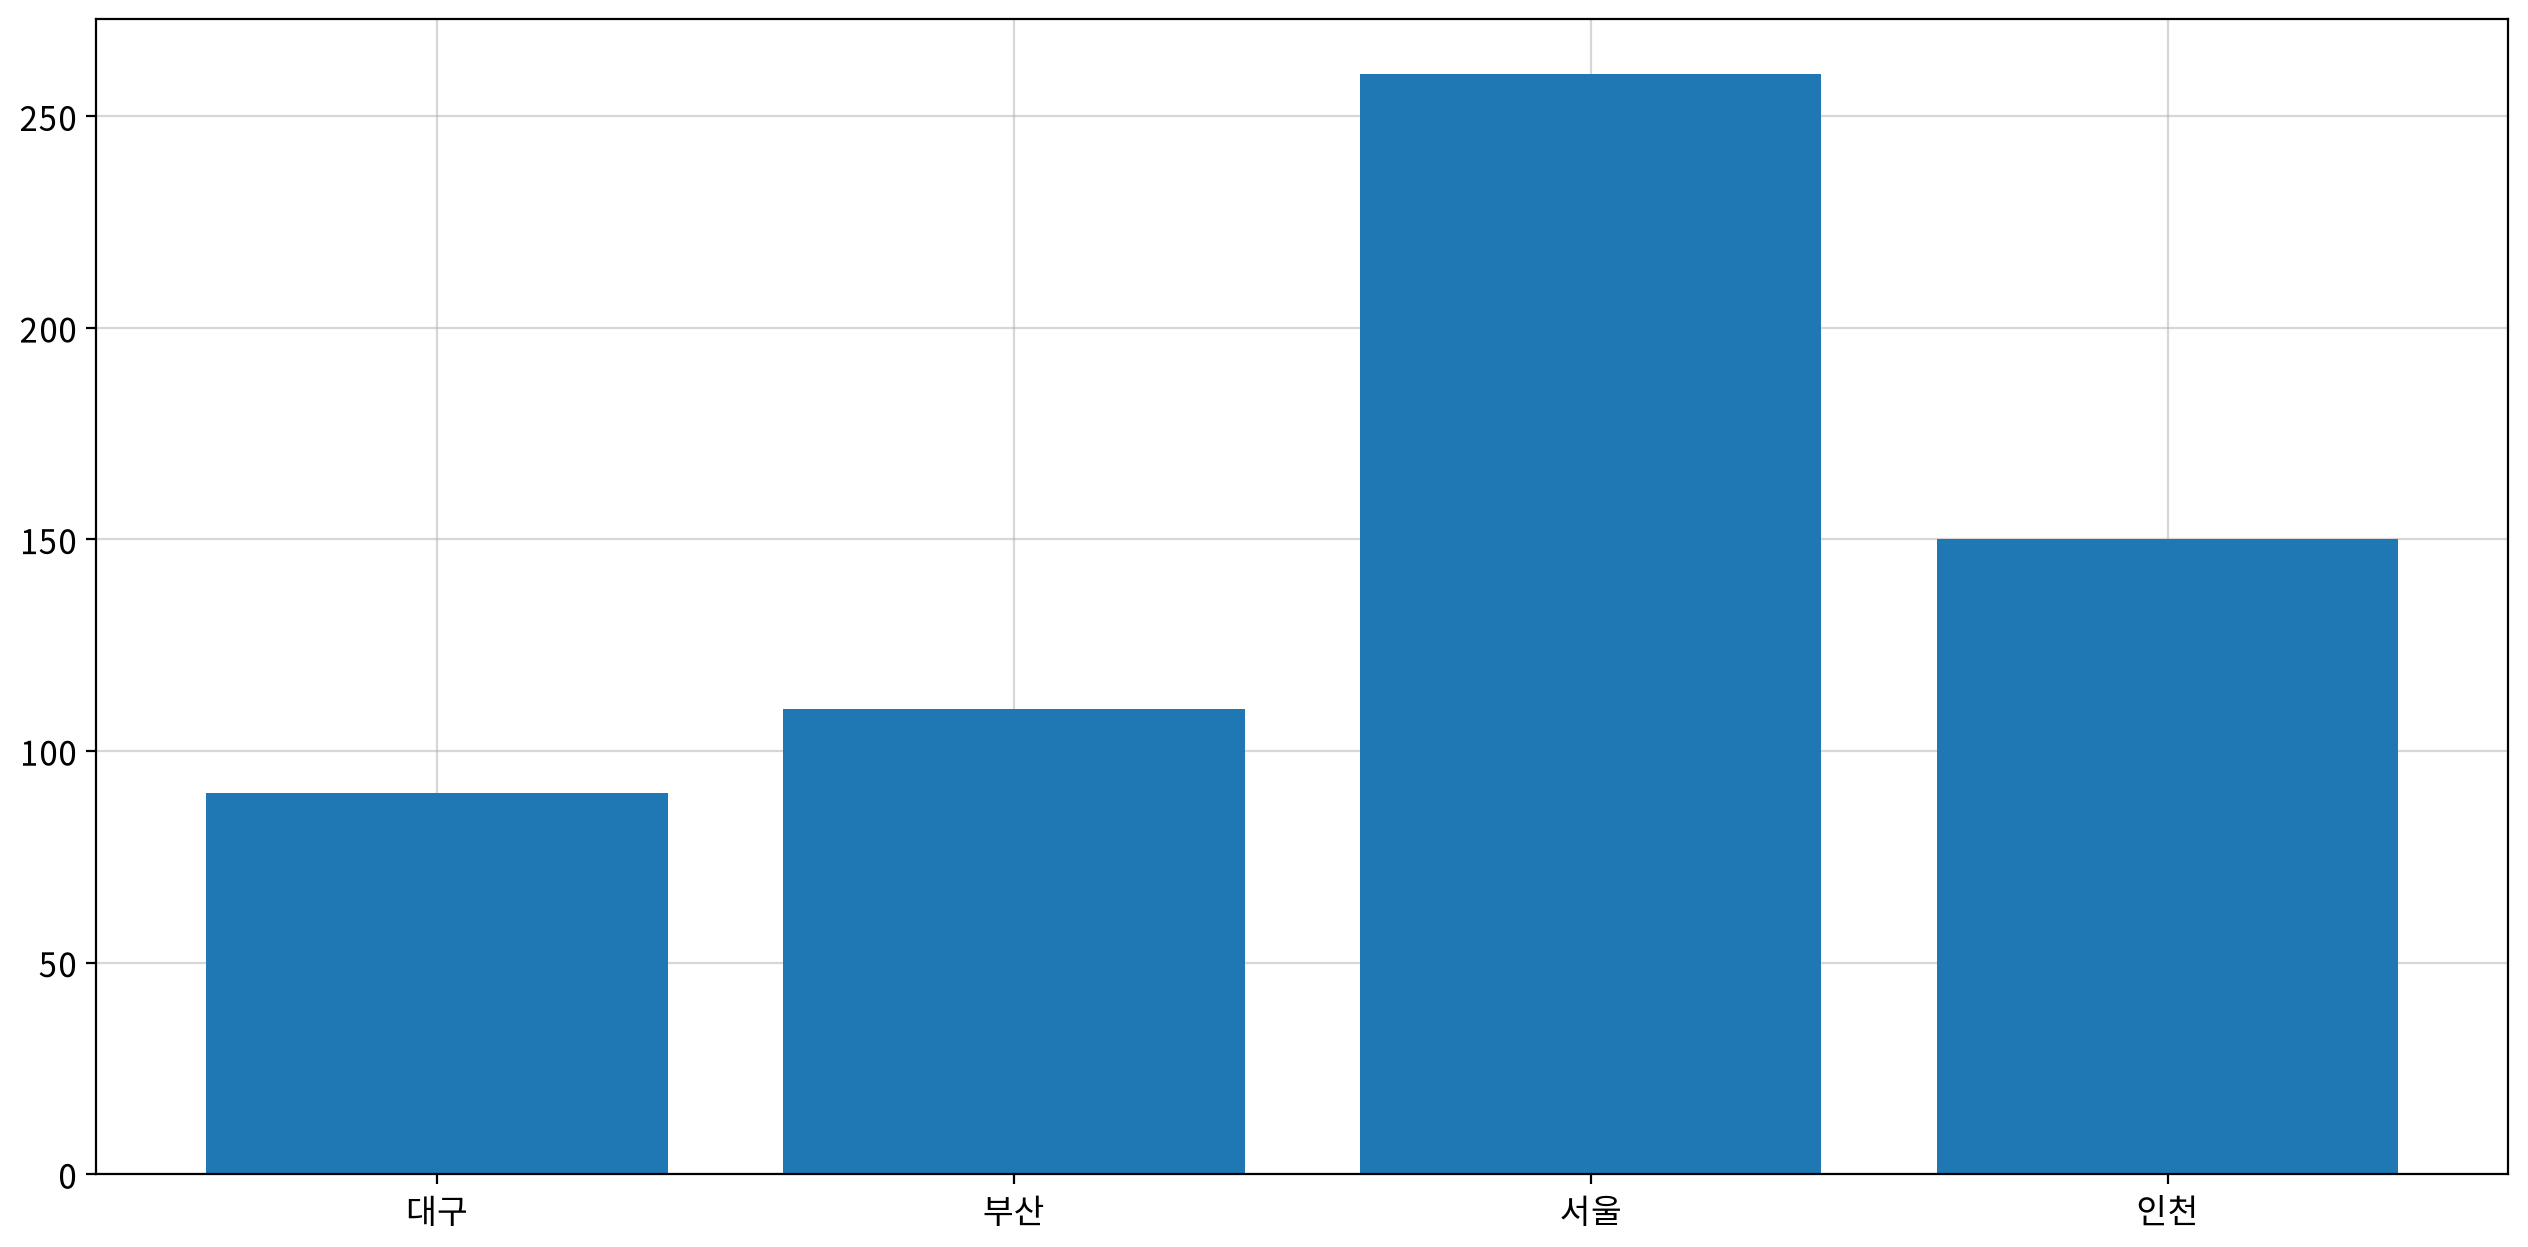

In [35]:
fig, ax = my_plot.init()             # 초기화 그래프 상태

# 지역별 IT산업 종사자 수에 대한 기본 막대 그래프
ax.bar(df.index, df['IT산업'])       # df.index에 대한 IT산업 종사자 수를 바그래프로 나타내라

# 그래프 확인
my_plot.show()

### 2. step2 - 막대 그래프 위에 새로운 데이터 쌓기

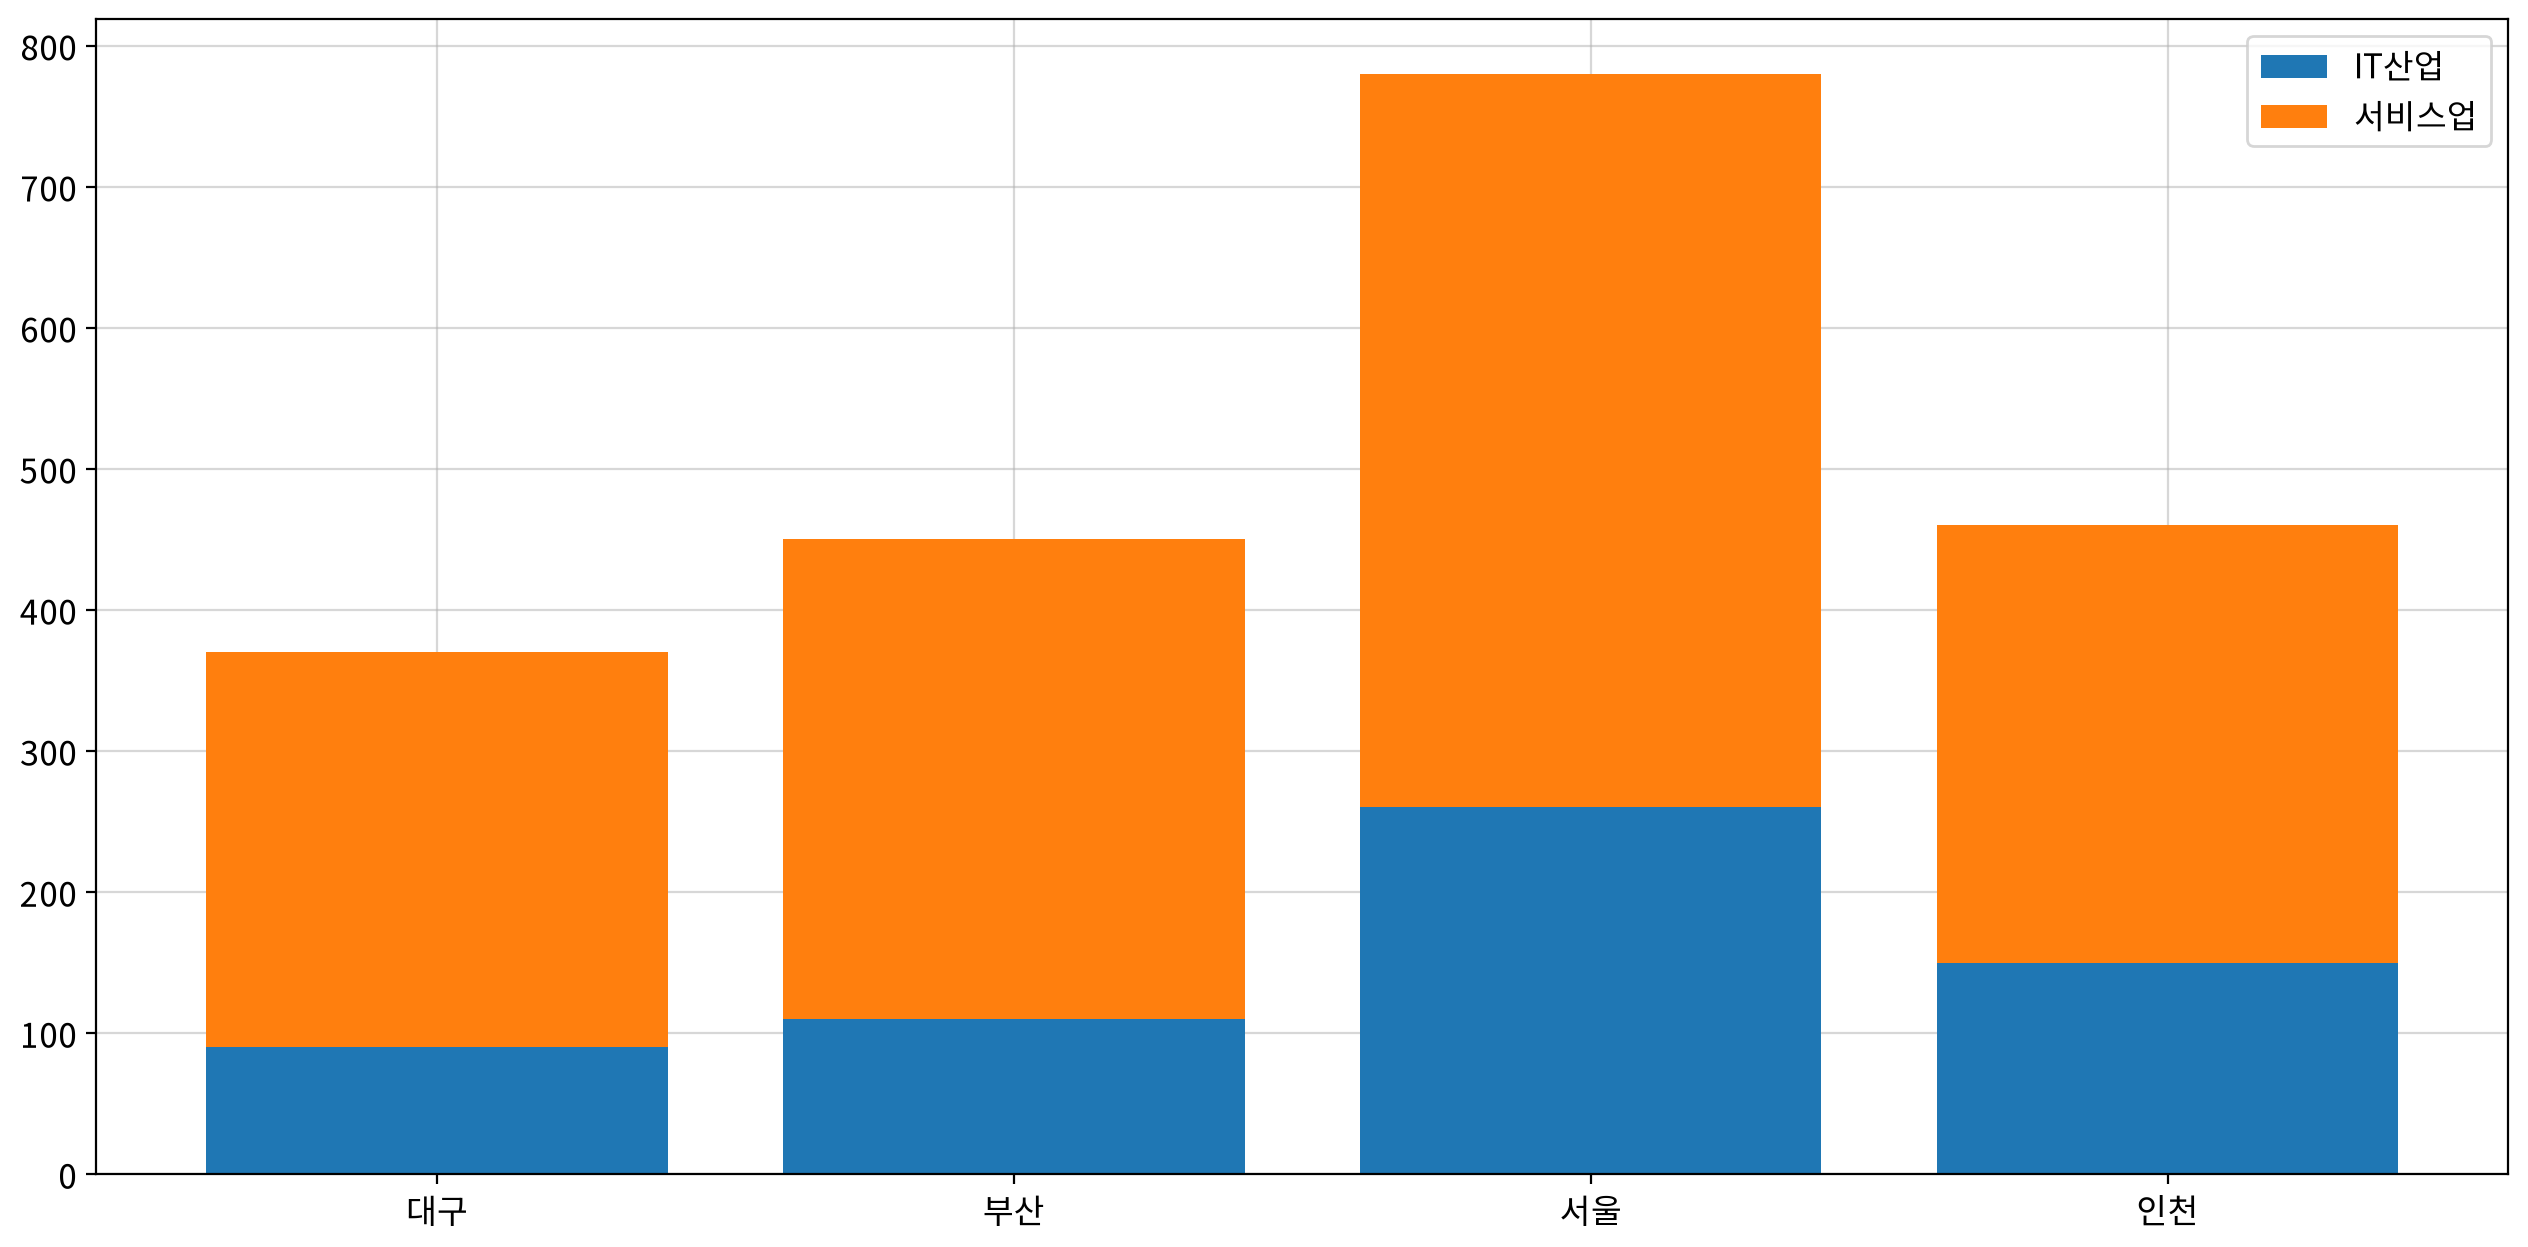

In [36]:
fig, ax = my_plot.init()

# 지역별 IT산업 종사자 수에 대한 기본 막대 그래프
ax.bar(df.index, df['IT산업'], label='IT산업')

# 기본 막대 그래프 위에 지역별 서비스업 종사자 수를 누적하여 표시
ax.bar(df.index, df['서비스업'], bottom=df['IT산업'], label='서비스업')

# 기본 막대 그래프와 누적 막대 그래프에 대한 범례 추가
# -> bbox_to_anchor=(1, 1) : 범주의 위치 오른쪽(1) 상단(1)
# -> bbox_to_anchor=(0, 0) : 범주 위치 왼쪽(0) 하단(0)
ax.legend()

# 그래프 출력
my_plot.show()

### 3. step3 - 추가 데이터 쌓기

- 필요한 만큼 데이터를 누적하여 쌓을 수 있다.

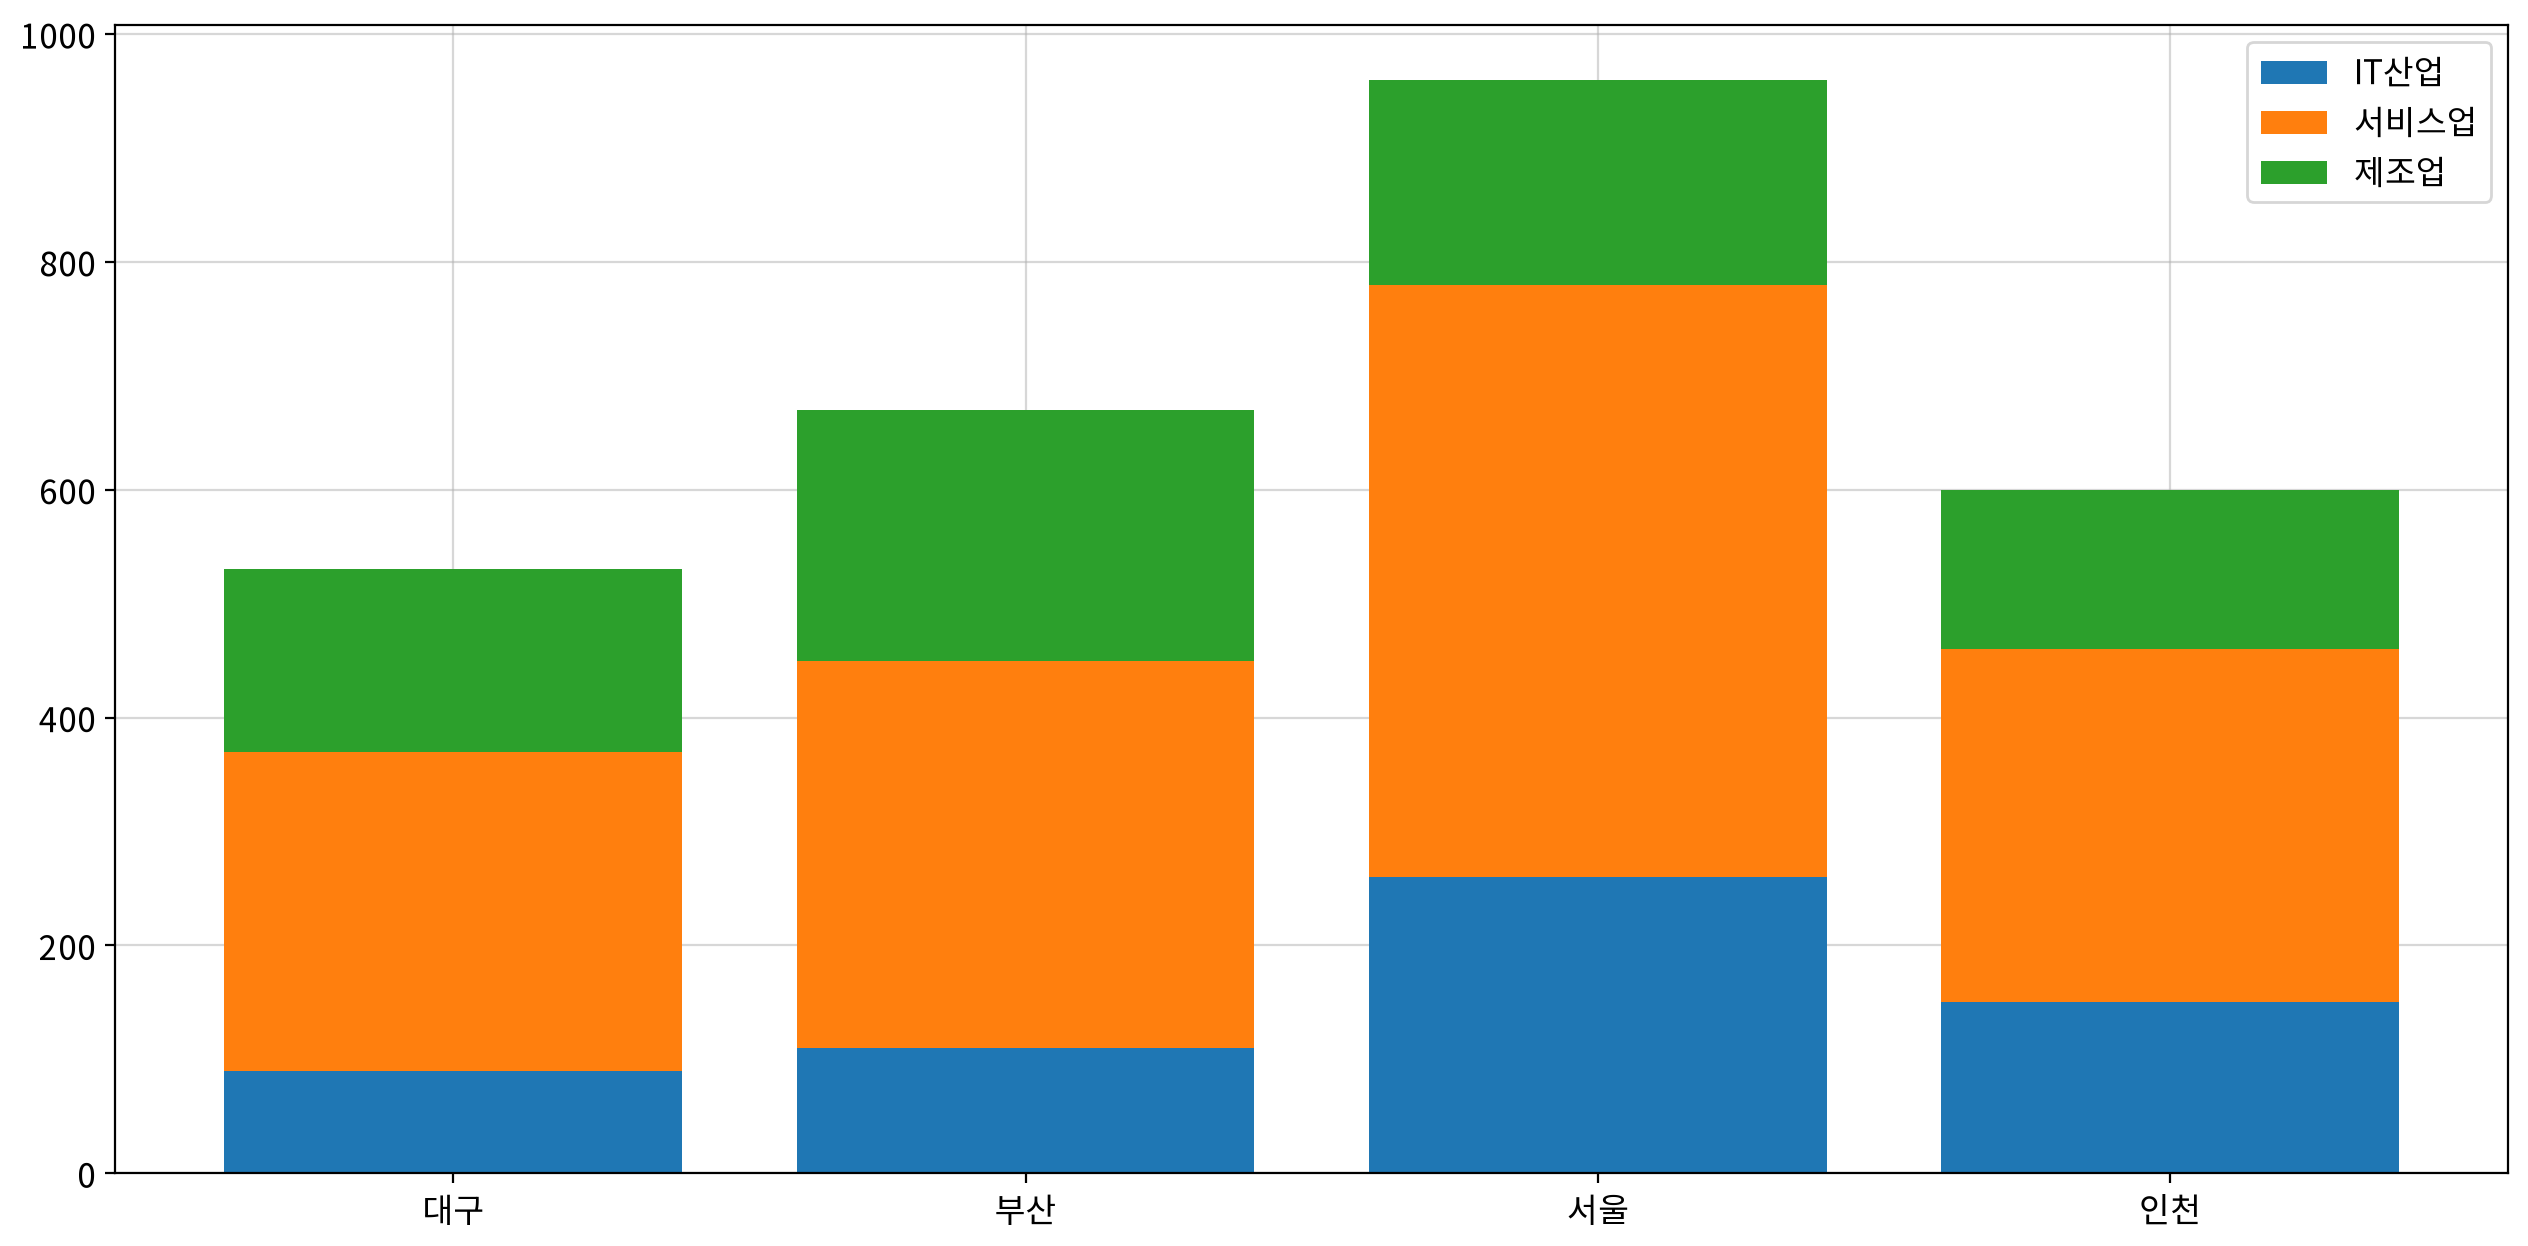

In [37]:
fig, ax = my_plot.init()

# 지역별 IT산업 종사자 수에 대한 기본 막대 그래프
ax.bar(df.index, df['IT산업'], label='IT산업')

# 기본 막대 그래프 위에 지역별 서비스업 종사자 수를 누적하여 표시
ax.bar(df.index, df['서비스업'], bottom=df['IT산업'], label='서비스업')

# 서비스업과 IT산업 위에 지역별 제조업 종사자 수를 누적하여 표시
ax.bar(df.index, df['제조업'], bottom=df['IT산업'] + df['서비스업'], label='제조업')

# 기본 막대 그래프, 서비스업 누적 막대 그래프, 제조업 누적 막대 그래프에 대한 범례 추가
ax.legend()

my_plot.show()

### 4. step4 - 각 영역 안에 수치값 표시하기

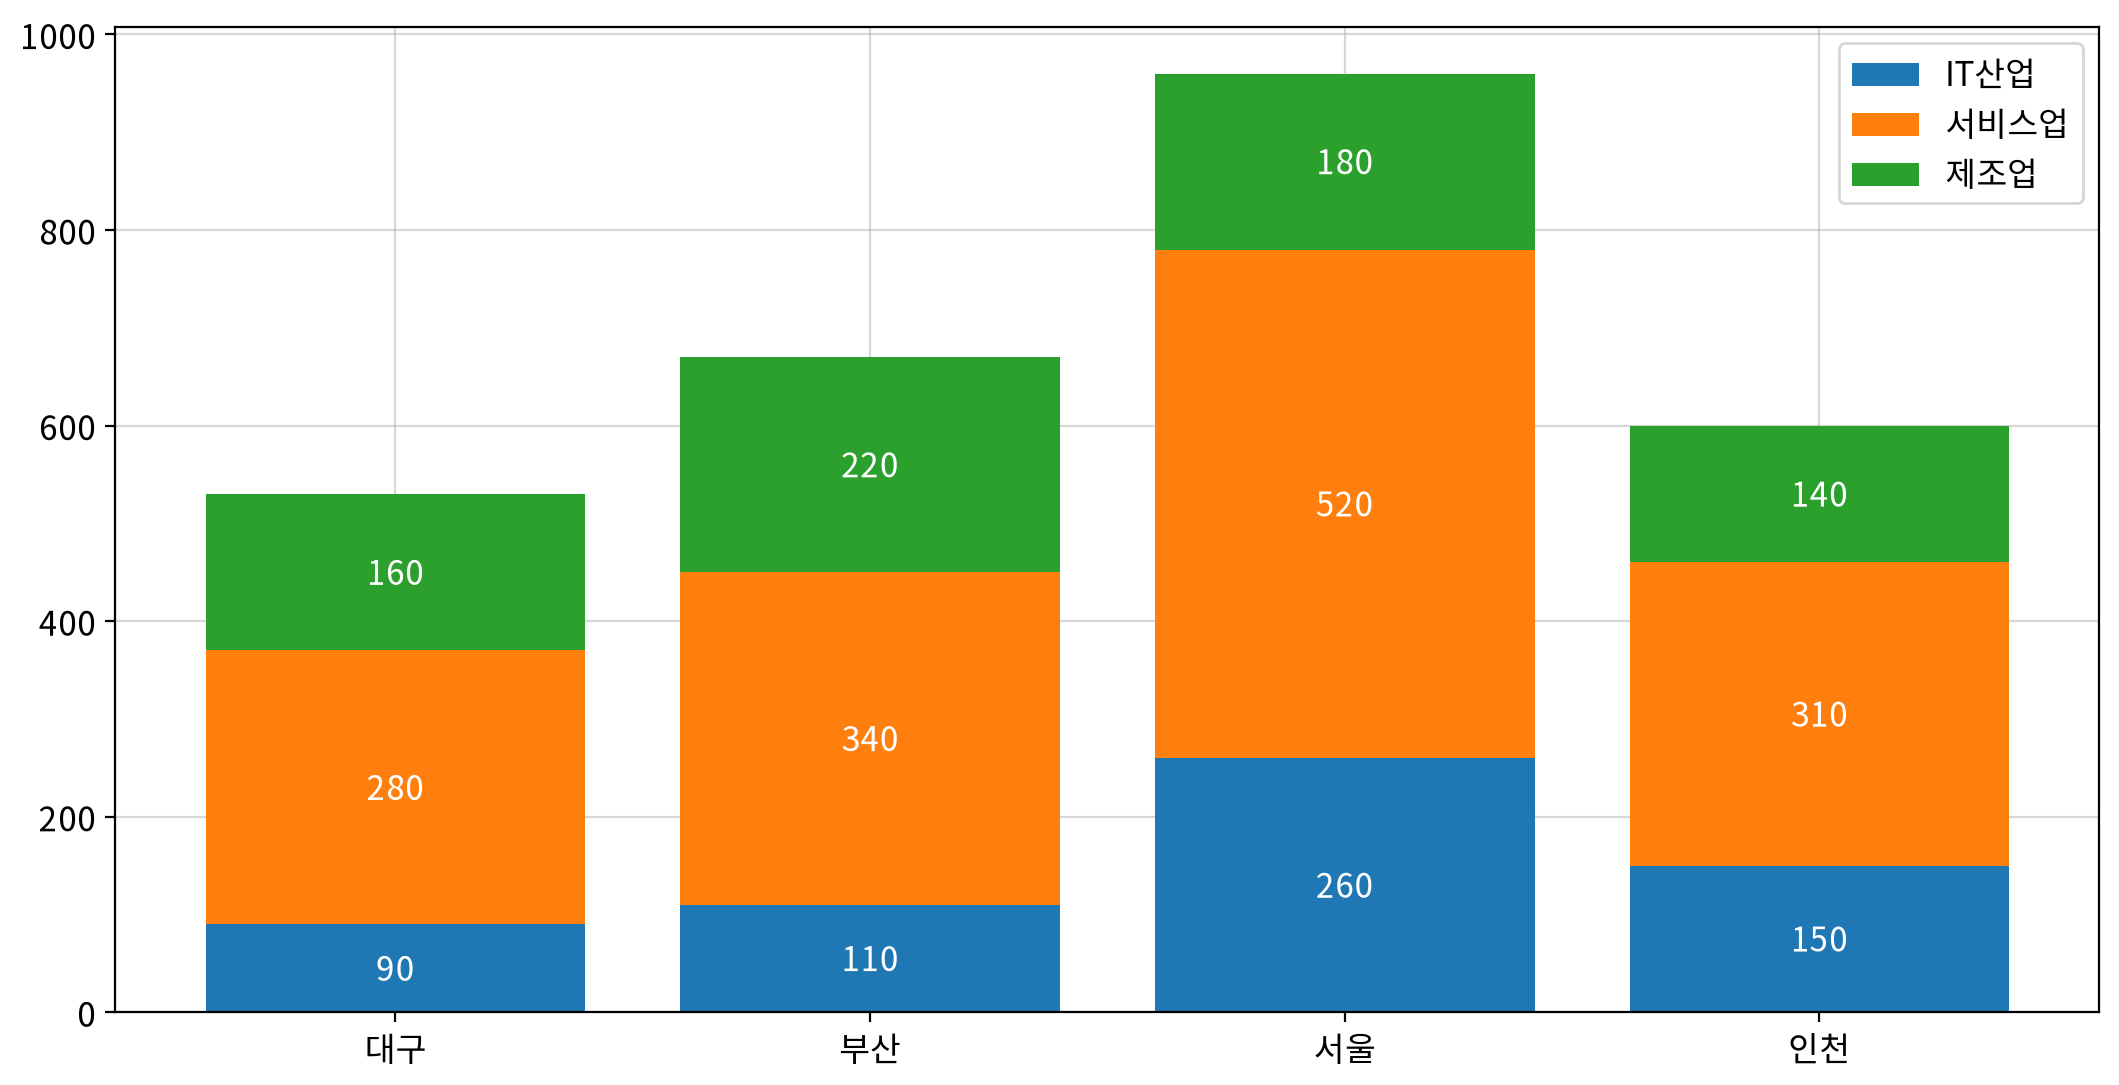

In [38]:
# fig, ax 초기화
fig, ax = my_plot.init()

# 지역별 IT산업 종사자 수에 대한 기본 막대 그래프
ax.bar(df.index, df['IT산업'], label='IT산업')

# 기본 막대 그래프 위에 지역별 서비스업 종사자 수를 누적하여 표시
ax.bar(df.index, df['서비스업'], bottom=df['IT산업'], label='서비스업')

# 서비스업과 IT산업 위에 지역별 제조업 종사자 수를 누적하여 표시
ax.bar(df.index, df['제조업'], bottom=df['IT산업'] + df['서비스업'], label='제조업')

# 기본 막대 그래프, 서비스업 누적 막대 그래프, 제조업 누적 막대 그래프에 대한 범례 추가
ax.legend()

# 각 막대 위에 종사자 수 표시
for i in df.index:
    ax.text(x=i, y=df['IT산업'][i] / 2, s=str(df['IT산업'][i]),
            ha='center', va='center', color='white', fontsize=12)
    ax.text(x=i, y=df['IT산업'][i] + df['서비스업'][i] / 2, s=str(df['서비스업'][i]),
            ha='center', va='center', color='white', fontsize=12)
    ax.text(x=i, y=df['서비스업'][i] + df['IT산업'][i] + df['제조업'][i] / 2, s=str(df['제조업'][i]),
            ha='center', va='center', color='White', fontsize=12)

## #03. 색상 팔레트 적용하기

### 1. seaborn의 팔레트에서 범주의 종류 수 만큼 색상 추출

In [39]:
# seaborn의 pastel color palette 사용
colors = sb.color_palette("Set2", 3)
colors

[(0.4, 0.7607843137254902, 0.6470588235294118),
 (0.9882352941176471, 0.5529411764705883, 0.3843137254901961),
 (0.5529411764705883, 0.6274509803921569, 0.796078431372549)]

### 2. 색상을 적용한 가로 누적 막대 그래프

- barh 함수를 사용한다.
  - `bottom`이 아닌 `left`를 사용한다.
  - 색상을 적용한다.
  - 텍스트 출력의 x좌표와 y좌표를 서로 바꿔서 지정한다.

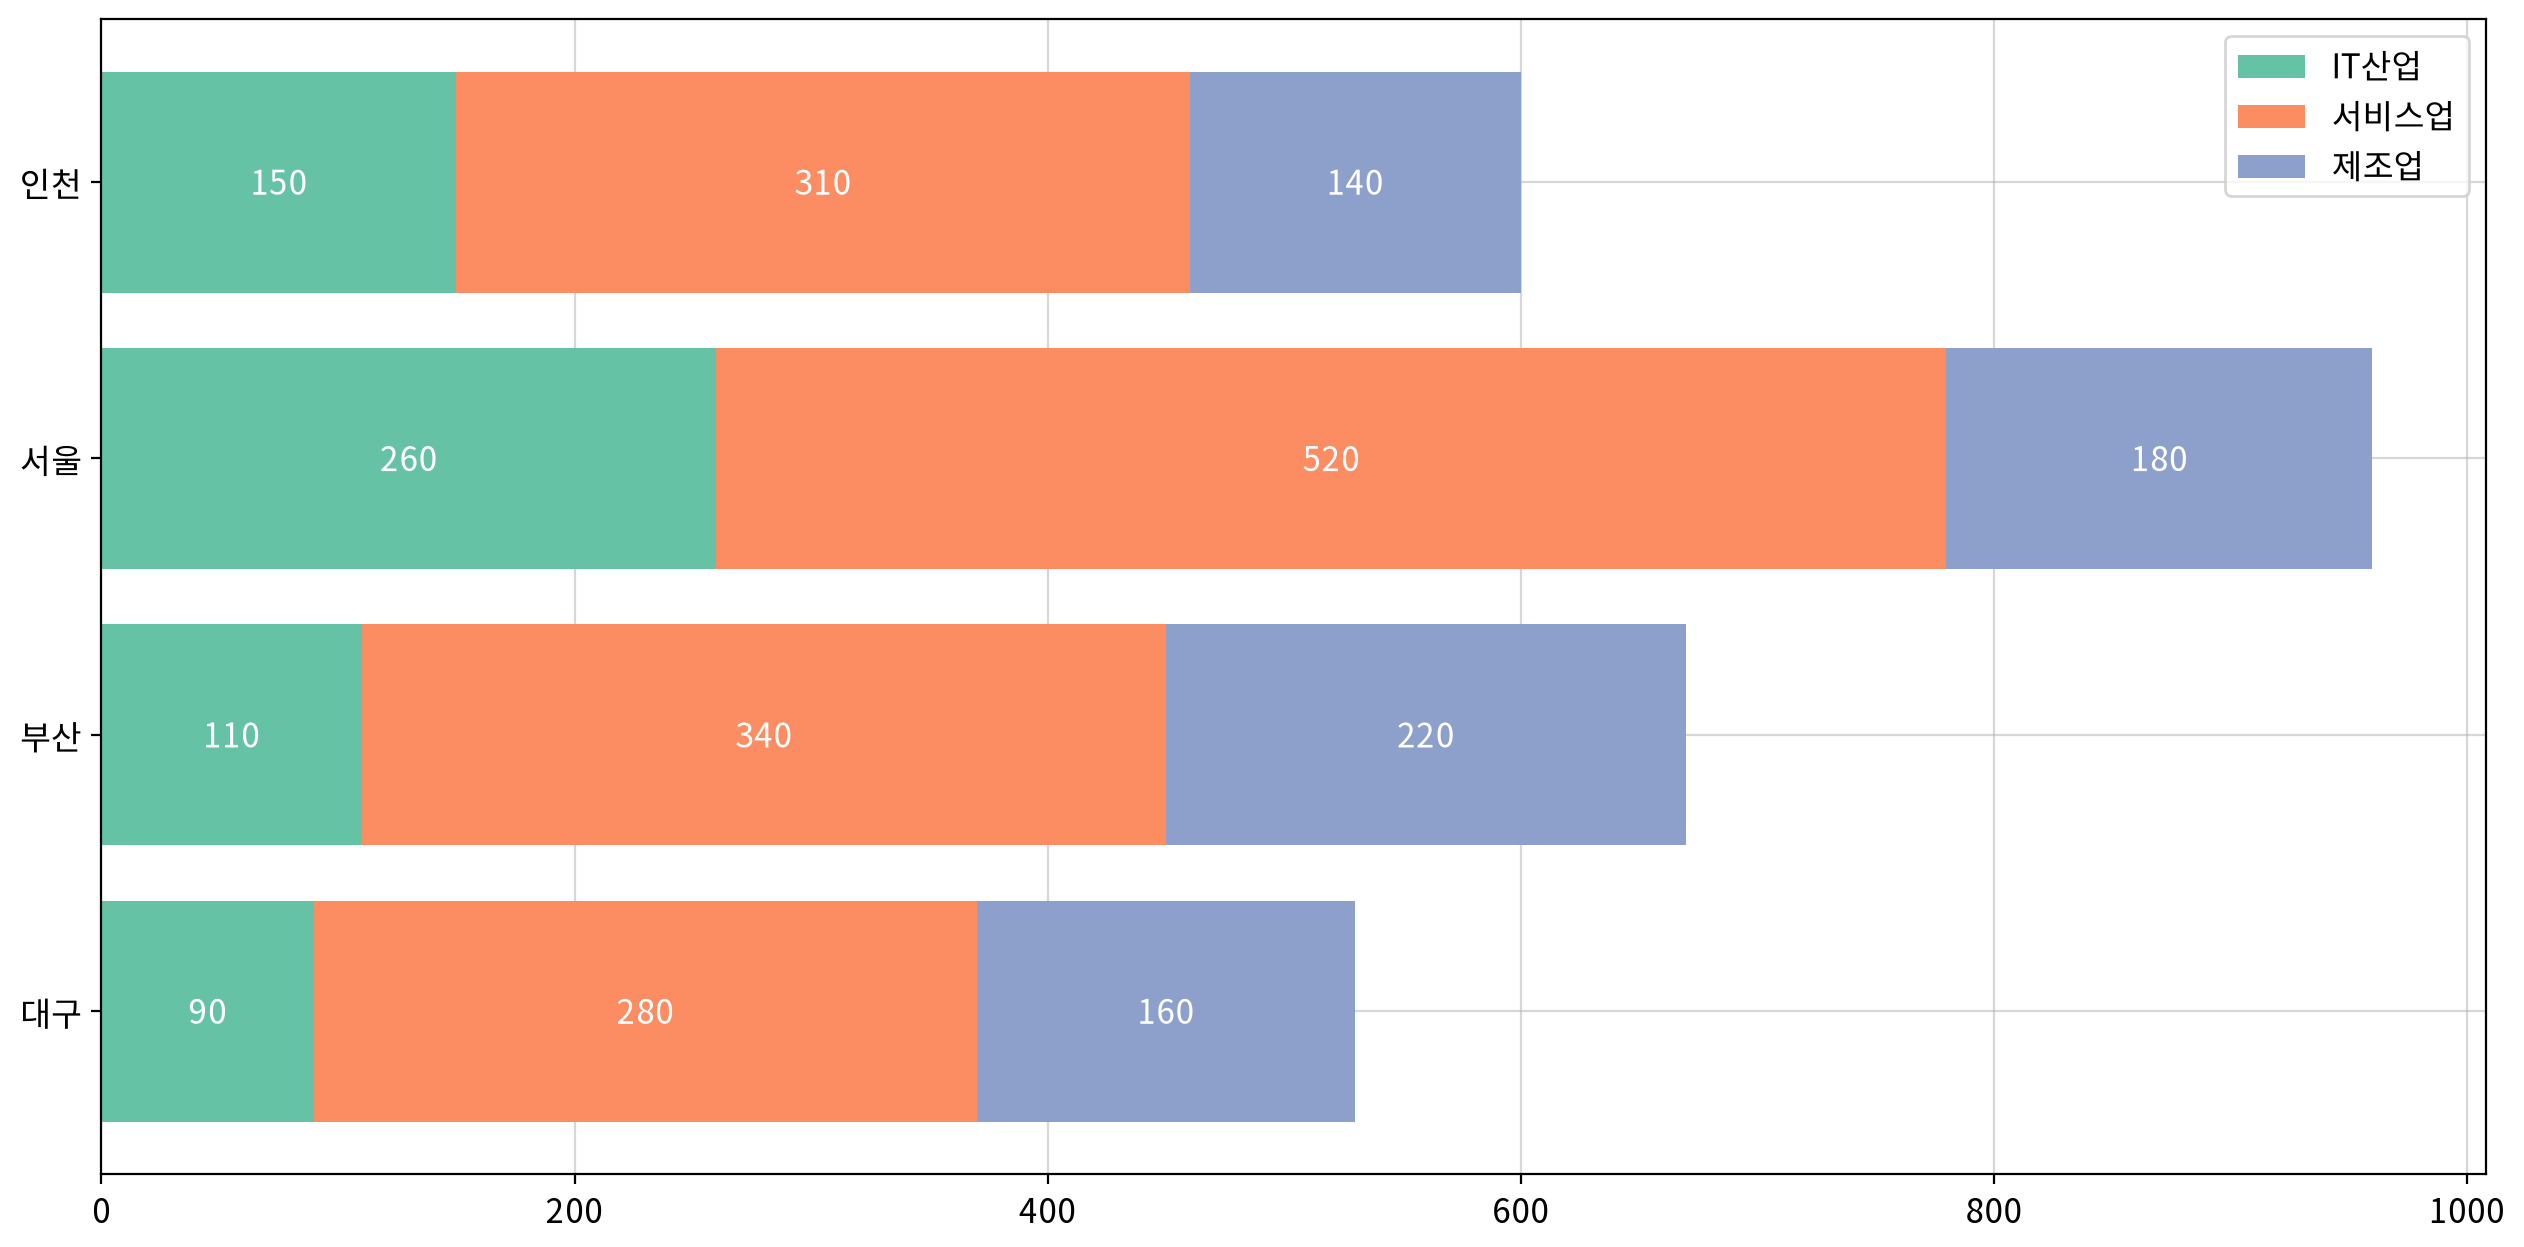

In [40]:
fig, ax = my_plot.init()

# 지역별 IT산업 종사자 수에 대한 기본 막대 그래프
ax.barh(df.index, df['IT산업'], label='IT산업', color=colors[0])

# 기본 막대 그래프 위에 지역별 서비스업 종사자 수를 누적하여 표시
ax.barh(df.index, df['서비스업'], left=df['IT산업'], label='서비스업', 
       color=colors[1])

# 서비스업과 IT산업 위에 지역별 제조업 종사자 수를 누적하여 표시
ax.barh(df.index, df['제조업'], left=df['IT산업'] + df['서비스업'], label='제조업', 
       color=colors[2])

# 기본 막대 그래프, 서비스업 누적 막대 그래프, 제조업 누적 막대 그래프에 대한 범례 추가
ax.legend(bbox_to_anchor=(1, 1))

# 각 막대 위에 종사자 수 표시
for i in df.index:
    ax.text(x=df['IT산업'][i] / 2, y=i, 
            s=str(df['IT산업'][i]), 
            ha='center', va='center', color='white', fontsize=12)
    ax.text(x=df['IT산업'][i] + df['서비스업'][i] / 2, y=i, 
            s=str(df['서비스업'][i]), 
            ha='center', va='center', color='white', fontsize=12)
    ax.text(x=df['IT산업'][i] + df['서비스업'][i] + df['제조업'][i] / 2, y=i, 
            s=str(df['제조업'][i]), 
            ha='center', va='center', color='white', fontsize=12)

my_plot.show()

## #04. 모듈화 기능 확인

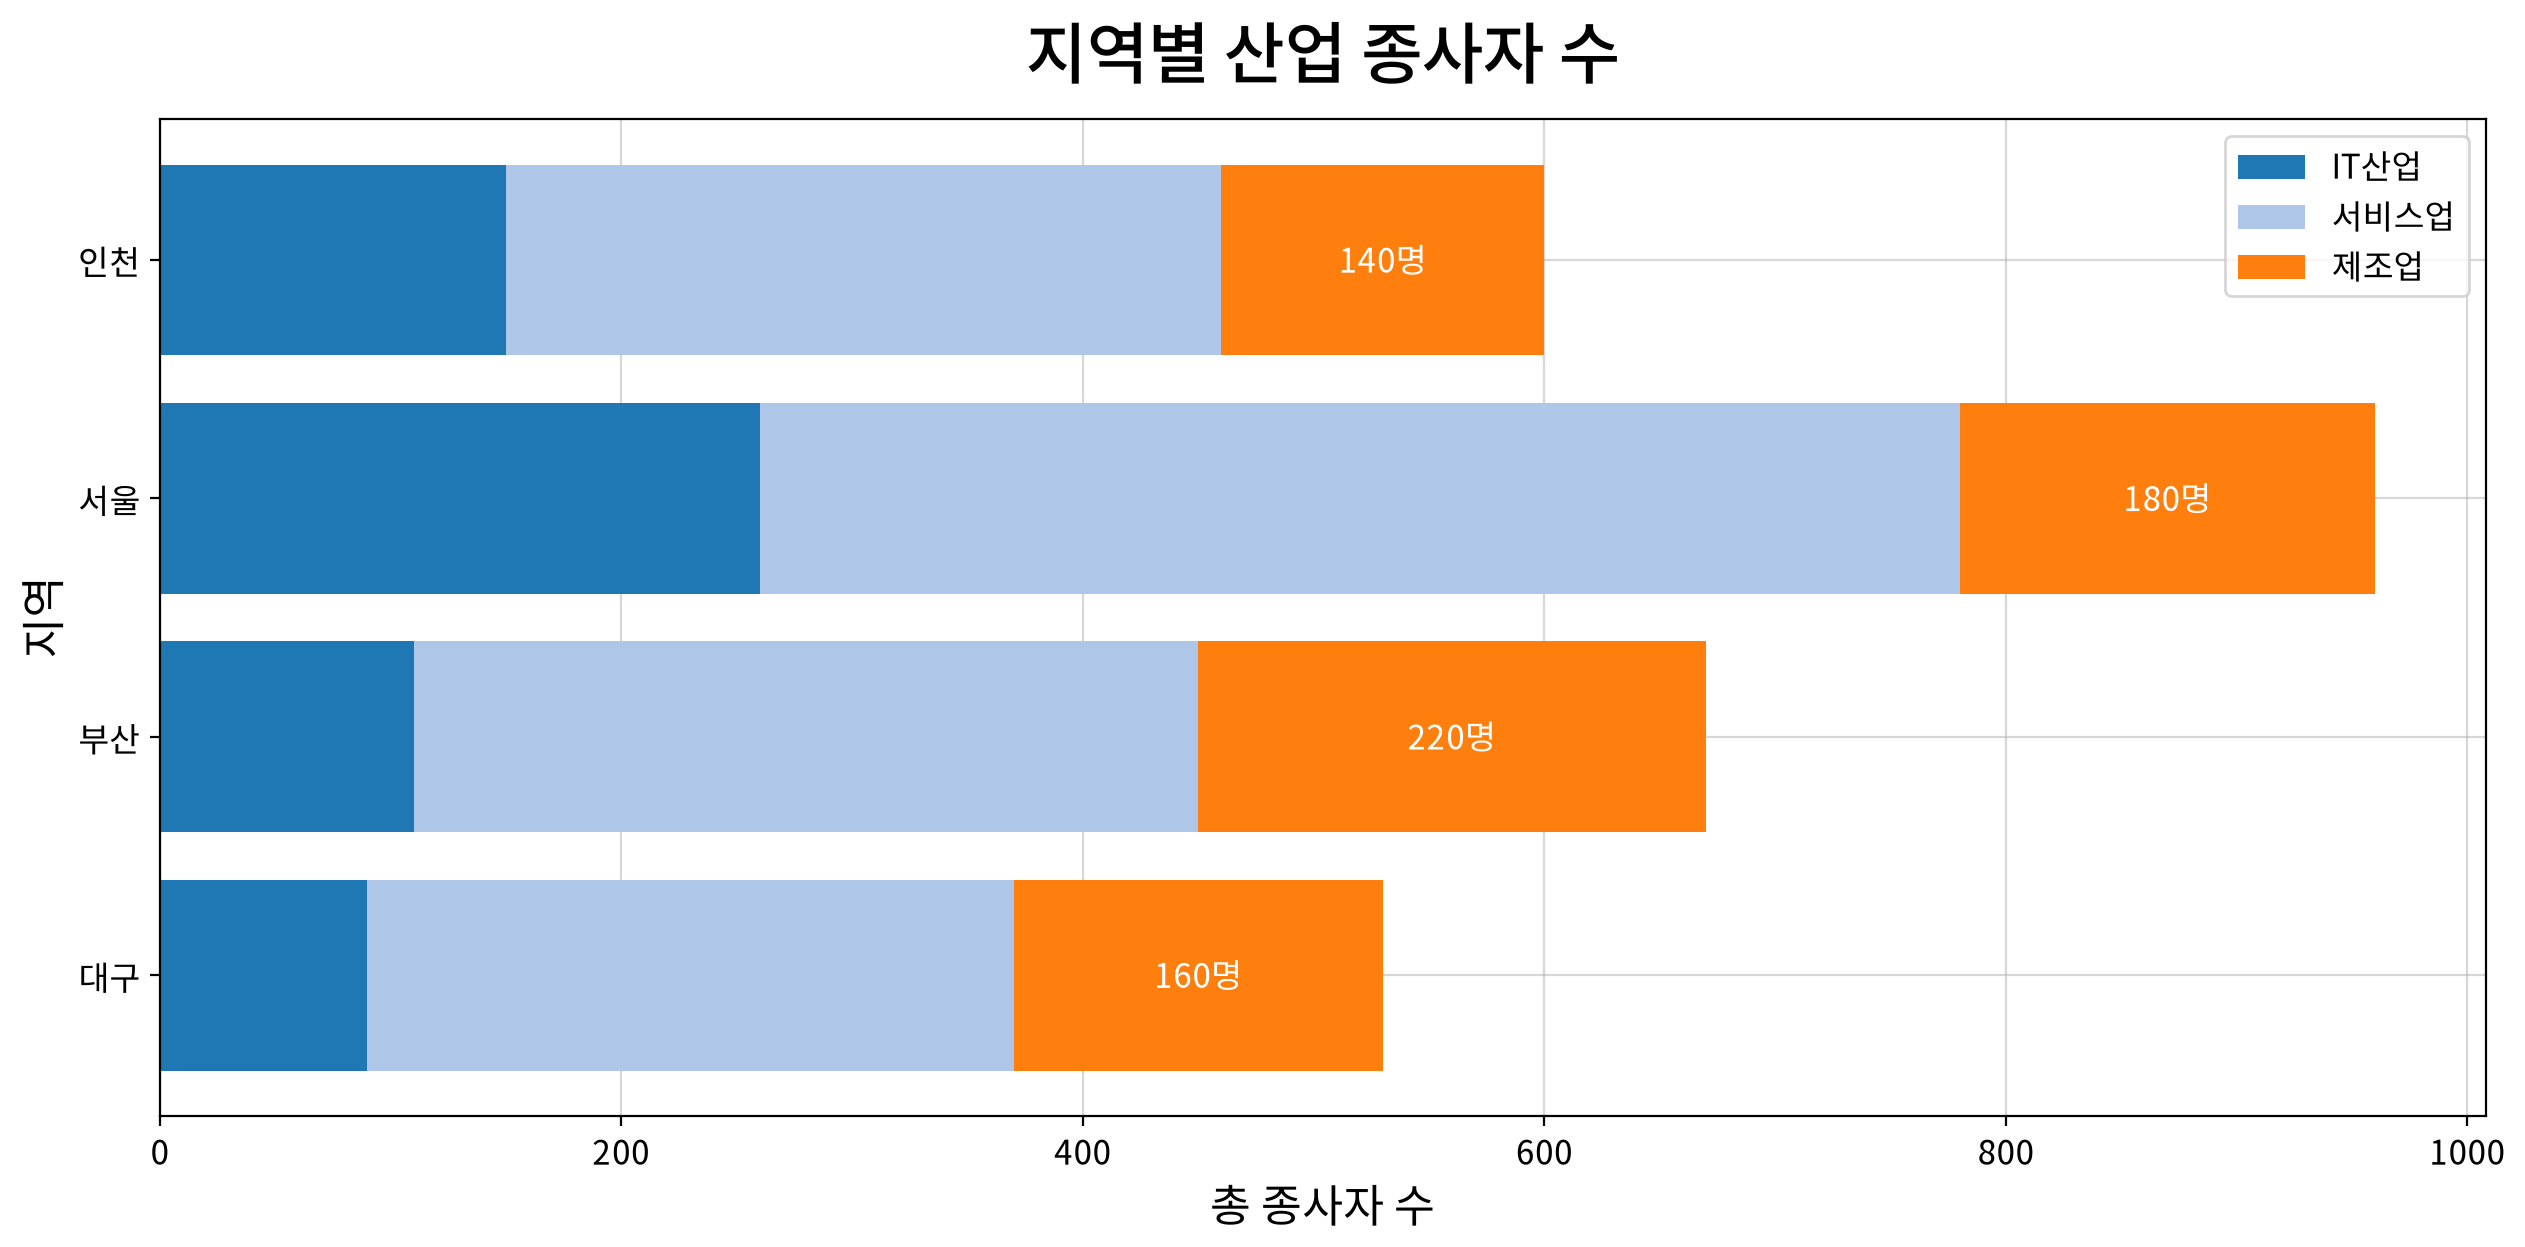

In [41]:
my_plot.stackplot(data=origin,              # 데이터프레임
                x="지역",                   # x축에 사용할 열 이름
                y="종사자 수",               # y축에 사용할 열 이름
                hue="산업",                 # 누적 막대그래프의 범주형 열 이름
                aggfunc=np.sum,             # 집계 함수 (기본값: np.sum) 
                orient='h',                 # 그래프 방향 ('v' -> 수직, 'h' -> 수평)
                text_format="{:d}명",       # 텍스트 포멧 (기본값: "{:.1f}")
                palette="tab20",            # 색상 팔레트 (기본값: None)
                title="지역별 산업 종사자 수", # 그래프 제목 (기본값: None)
                xlabel="총 종사자 수",       # x축 레이블 (기본값: None)
                ylabel="지역")              # y축 레이블 (기본값: None)

#### 💡 인사이트

- 📍 지역별 총 종사자 수는 서울 960명, 부산 670명, 인천 600명, 대구 530명 순임.
- 🥇 모든 지역에서 서비스업 종사자 수가 가장 큼.
- 🏙️ 서울은 IT산업 260명, 서비스업 520명, 제조업 180명으로 세 산업 모두에서 가장 큰 값을 보임.
- 🏭 제조업 종사자 수는 부산 220명으로 가장 크고, 서울 180명, 대구 160명, 인천 140명 순임.
- 💻 IT산업 종사자 수는 서울 260명으로 가장 크고, 인천 150명, 부산 110명, 대구 90명 순임.
- ➕ 서비스업과 제조업 합계는 서울 700명, 부산 560명, 인천 450명, 대구 440명임.
- 📊 서비스업 비중은 대구가 약 52.8%(280/530)로 가장 높고, 서울이 약 54.2%(520/960)로 가장 낮음.

## 연습문제. 다이아몬드 컷팅 등급별 색상의 가격 평균 비교
#### 데이터셋 : diamonds_qtcheck
#### 이 데이터 셋을 활용하여 컷팅 등급별 색상의 가격 평균을 누적 막대 그래프로 시각화하고 문제에 답하시오.

In [11]:
# 0. 필요한 모듈 불러오기
from jussam import load_data
from helper import *
from pandas import pivot_table
import seaborn as sb
import numpy as np

In [30]:
# 1. 데이터 불러오기
df = load_data('diamonds_qtcheck')
df.info()
df

📚 다이아몬드 데이터셋의 품질 검사 완료 버전 (출처: 자체 정제)

    field    description
--  -------  -------------------------------------------------------------------
 0  price    다이아몬드 가격 (USD, $326 ~ $18,823)
 1  carat    중량 (0.2~5.01)
 2  cut      컷 품질 (Fair, Good, Very Good, Premium, Ideal)
 3  color    색상 등급 - J (worst) to D (best)
 4  clarity  투명도 등급 (I1 (worst), SI2, SI1, VS2, VS1, VVS2, VVS1, IF (best))
 5  x        길이 mm (0~10.74)
 6  y        너비 mm (0--58.9)
 7  z        두께 mm (0--31.8)
 8  depth    비율 정보 = z / mean(x, y) = 2 * z / (x + y) (43--79)
 9  table    다이아몬드의 가장 넓은 지점에 비해 상단(테이블)의 너비 (43--95)

<class 'pandas.DataFrame'>
RangeIndex: 53794 entries, 0 to 53793
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype   
---  ------   --------------  -----   
 0   price    53794 non-null  int64   
 1   carat    53794 non-null  float64 
 2   cut      53794 non-null  category
 3   color    53794 non-null  category
 4   clarity  53794 non-null  category
 5   x        53794 non-null  f

,price,carat,cut,color,clarity,x,y,z,depth,table
0,326,0.230,Ideal,E,SI2,3.950,3.980,2.430,61.500,55.000
1,326,0.210,Premium,E,SI1,3.890,3.840,2.310,59.800,61.000
2,327,0.230,Good,E,VS1,4.050,4.070,2.310,56.900,65.000
3,334,0.290,Premium,I,VS2,4.200,4.230,2.630,62.400,58.000
4,335,0.310,Good,J,SI2,4.340,4.350,2.750,63.300,58.000
...,...,...,...,...,...,...,...,...,...,...
53789,2757,0.720,Ideal,D,SI1,5.750,5.760,3.500,60.800,57.000
53790,2757,0.720,Good,D,SI1,5.690,5.750,3.610,63.100,55.000
53791,2757,0.700,Very Good,D,SI1,5.660,5.680,3.560,62.800,60.000
53792,2757,0.860,Premium,H,SI2,6.150,6.120,3.740,61.000,58.000


In [31]:
# 2. 데이터 pivot_table(cut등급을 index설정)
df2 = pivot_table(df, index='color', columns='cut', values='price', 
                  aggfunc=np.mean, fill_value=0)

df2.info()
df2

<class 'pandas.DataFrame'>
CategoricalIndex: 7 entries, D to J
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Fair       7 non-null      float64
 1   Good       7 non-null      float64
 2   Ideal      7 non-null      float64
 3   Premium    7 non-null      float64
 4   Very Good  7 non-null      float64
dtypes: float64(5)
memory usage: 350.0 bytes


cut,Fair,Good,Ideal,Premium,Very Good
color,,,,,
D,4291.061,3408.108,2635.239,3634.493,3472.662
E,3689.743,3425.749,2601.217,3542.385,3215.471
F,3834.751,3497.254,3378.721,4327.297,3777.724
G,4227.000,4114.075,3728.446,4498.783,3874.210
H,5091.308,4246.585,3896.114,5217.907,4524.835
I,4607.534,5032.471,4452.125,5934.466,5257.477
J,4975.655,4587.833,4922.871,6287.733,5110.304


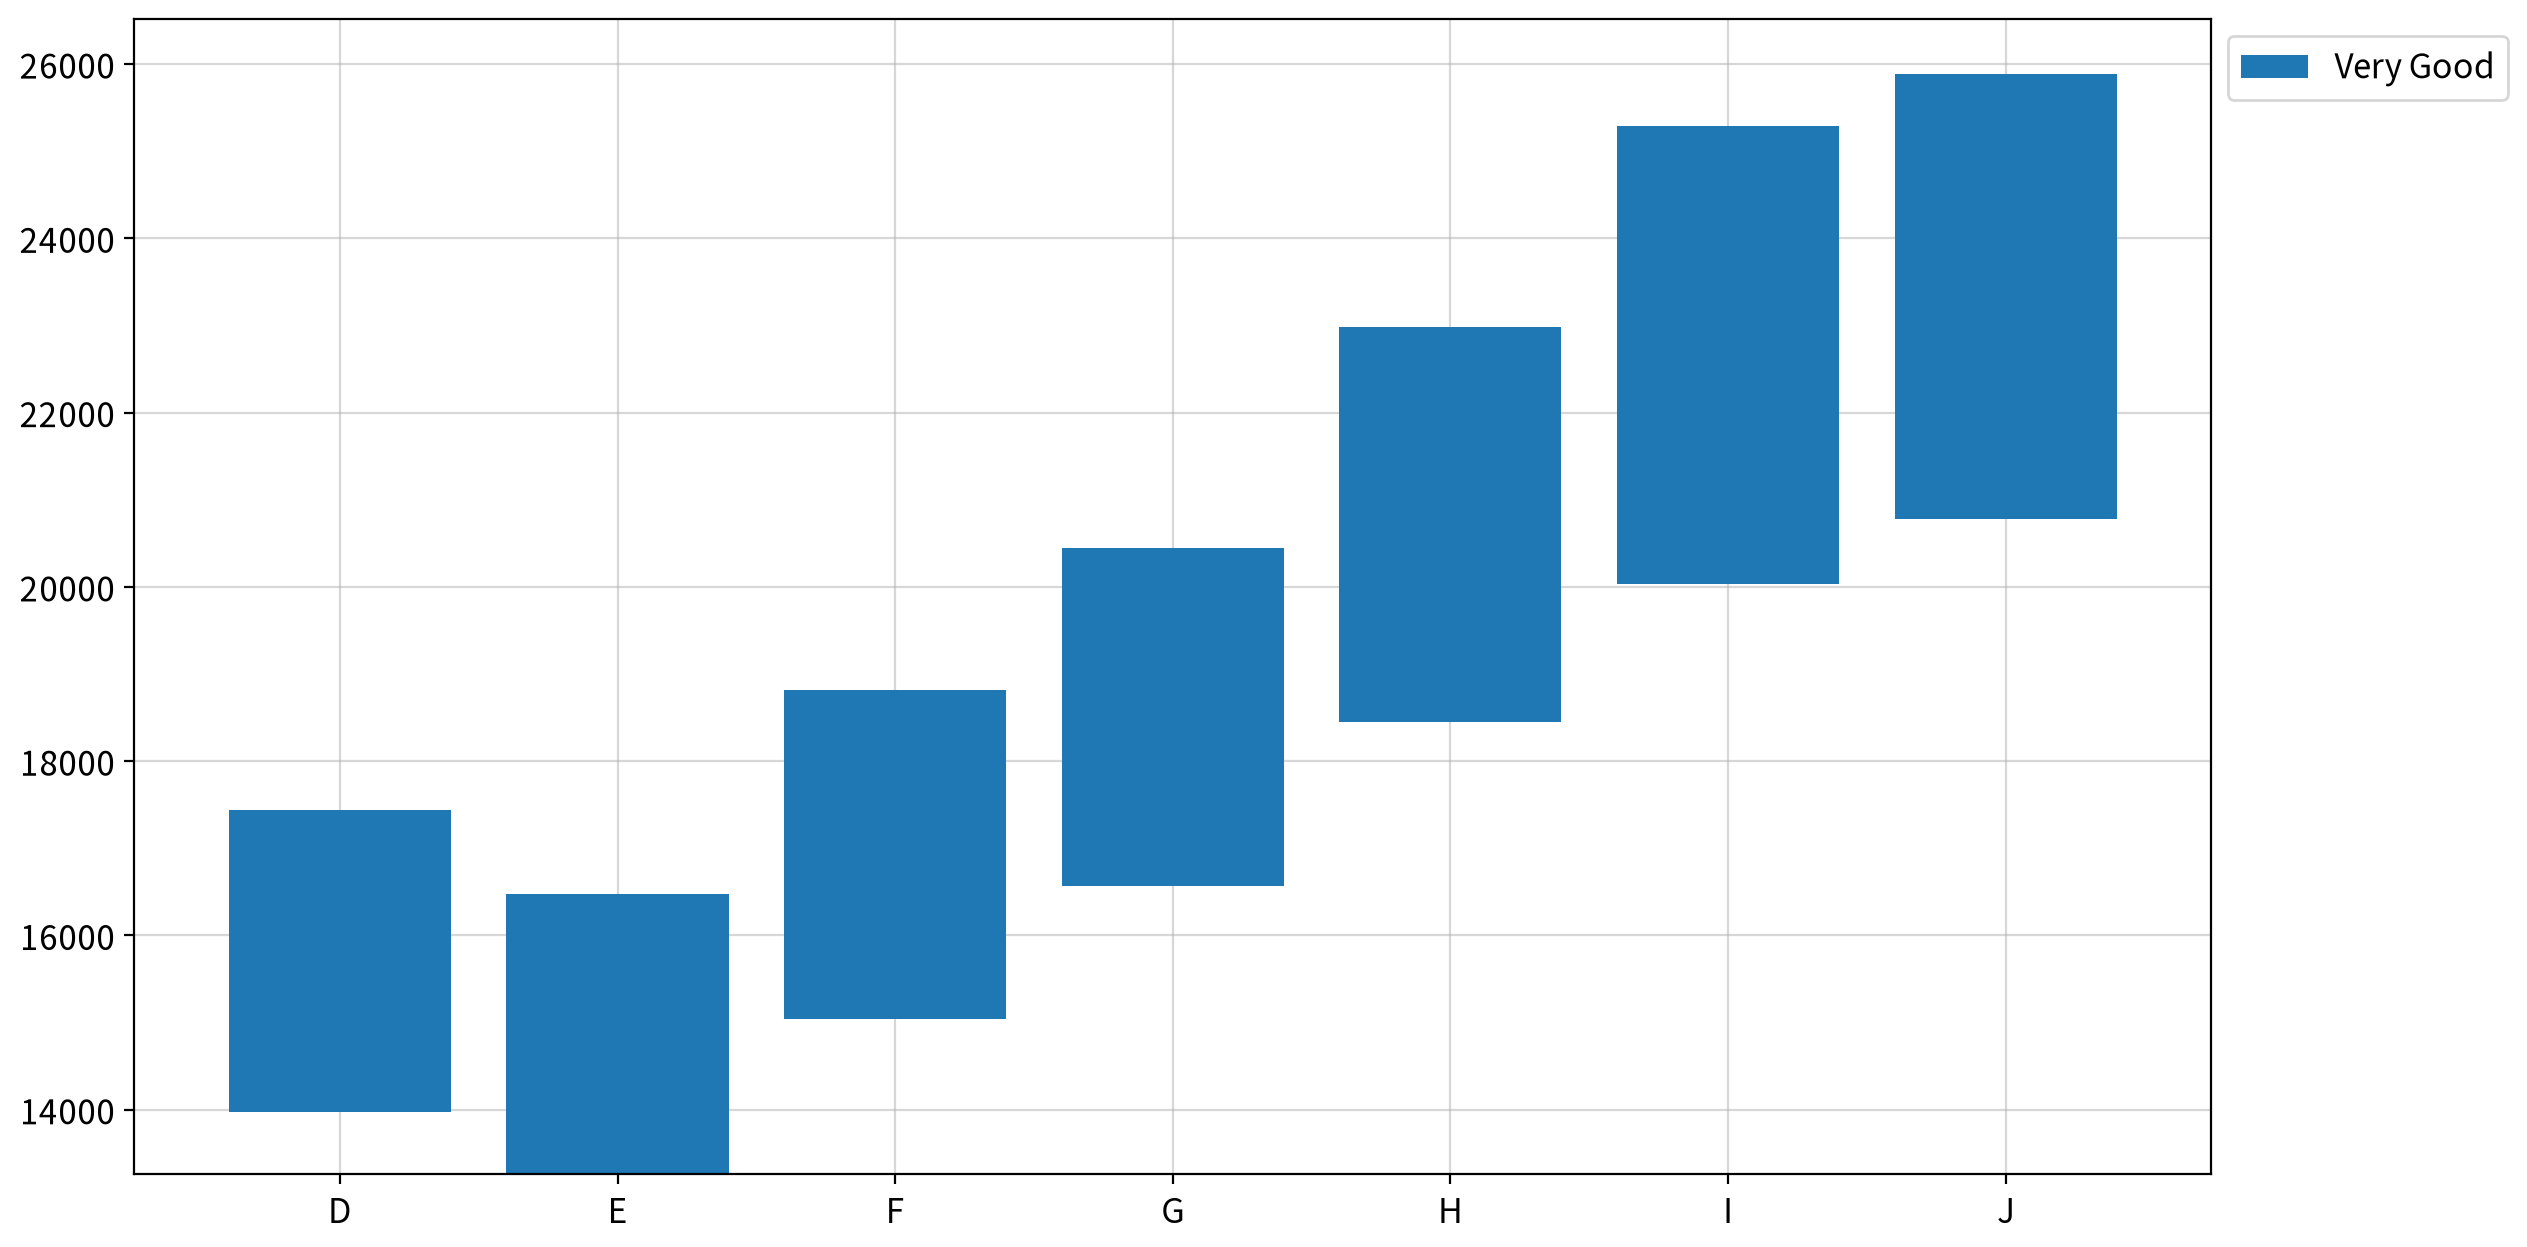

In [32]:
# 3. cut 등급별 컬러에 대한 평균가격 그래프
fig, ax = my_plot.init()

ax.bar(df2.index, df2['Very Good'], bottom=df2['Fair'] + df2['Good'] + df2['Ideal'] + df2['Premium'], label='Very Good')

ax.legend(bbox_to_anchor=(1,1))

my_plot.show()